# Chapter 6. The sentence Meera acts on

**Week 1, Monday. Chapter 6 of 6: one sentence Meera can sign against, and what one quarter
cannot tell her.**

**The need.** Meera will not read five notebooks. She needs the answer, the evidence, and the
limit of the evidence, in the time it takes to read one sentence, and marketing will read the
same sentence looking for the weakest number in it.

| | |
|---|---|
| The metric at stake | The repeat picture: who came back, who has not, and who has not had time to |
| Who asks | Meera, who signs; Kavya, who reviews it first; the marketing lead, who will attack it |
| What a wrong number costs | A sentence that says "70 percent of customers are lost" either panics the room or hands marketing an easy rebuttal, and the team loses the trust the week depends on |
| A real company with the same question | Klarna reported that its AI assistant handled two-thirds of customer-service chats in its first month (Klarna, 27 February 2024); fifteen months later its chief executive said the focus on cost had lowered quality (Fortune, 9 May 2025). A first window's number read as the verdict is the risk this chapter's caveat guards against. |

Chapter 5 chose frequency first: 16 of 23 customers bought once and 7 came back, and the
lifts multiply. This chapter turns that into the sentence, and stress-tests the one number in
it most likely to be misread.

> **Kavya's review.** One sentence, four parts in this order: the evidence with its window, the
> branch, what the window cannot show, and what happens to the Rs 12 crore.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

ORDERS = kit.load_records()

from datetime import date
for order in ORDERS:
    order["amount"] = int(order["amount"])
start = date.fromisoformat(min(o["order_date"] for o in ORDERS))
end = date.fromisoformat(max(o["order_date"] for o in ORDERS))
by_customer = {}
for order in ORDERS:
    by_customer.setdefault(order["customer_id"], []).append(date.fromisoformat(order["order_date"]))
customers = len(by_customer)
once_ids = [cid for cid, days in by_customer.items() if len(days) == 1]
print(f"{len(ORDERS)} orders from {start} to {end}, {(end - start).days + 1} days; {customers} customers, {len(once_ids)} bought once")

30 orders from 2026-07-01 to 2026-09-26, 88 days; 23 customers, 16 bought once


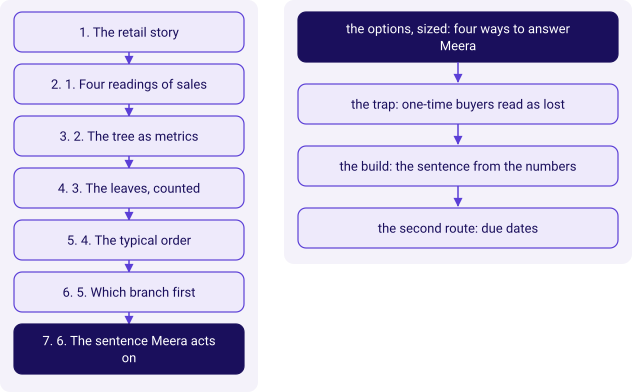

In [2]:
kit.side_by_side(
    kit.ladder(['The retail story', '1. Four readings of sales', '2. The tree as metrics', '3. The leaves, counted', '4. The typical order', '5. Which branch first', '6. The sentence Meera acts on'], lit=6, show=False),
    kit.vflow(['the options, sized: four ways to answer Meera', 'the trap: one-time buyers read as lost', 'the build: the sentence from the numbers', 'the second route: due dates'], lit=0, show=False),
)

## The options

Four ways to hand Meera the answer, sized in the reader's time and in what can go wrong.

| Option | Her reading time | The decision it carries | How it gets misread |
|---|---|---|---|
| A. One number: "orders per customer, 1.30" | two seconds | none; she has to supply it | as good or bad news with no benchmark |
| B. The tree as a table of every leaf | a minute or more | none; she draws the conclusion | she picks the number that suits the room |
| C. One sentence: evidence, branch, caveat, the ask | about twenty seconds | open frequency, hold the budget until Tuesday | only if a number in it is misread, which the trap below tests |
| D. A dashboard refreshed every week | weeks to build | whatever she looks at | a chart with no denominator |

**The best-fit call.** C: it is the only option that carries a decision and its limit together.
**What would change it:** when the question becomes weekly, as it does when Meera's chief of
staff asks for the leadership deck in Week 2, D earns its build cost, with C as its headline.

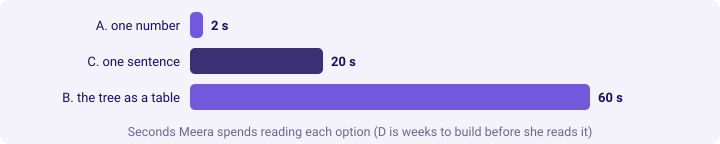

In [3]:
reading = [("A. one number", 2), ("C. one sentence", 20), ("B. the tree as a table", 60)]
kit.bars(reading, fmt=lambda v: f"{v} s", lit=(1,),
         title="Seconds Meera spends reading each option (D is weeks to build before she reads it)")
kit.check("the sentence is the one option that carries a decision inside half a minute",
          [n for n, t in reading if t <= 30 and n.startswith("C")] == ["C. one sentence"])

## 1. The trap: one-time buyers read as lost customers

**Predict before you run.** 16 of the 23 customers bought only once in the quarter. What share
of Kalpa's customers can you say are lost?

- a) About 70 percent, 16 of 23.
- b) 30 percent, the ones who came back.
- c) None can be called lost from this file alone, and some are too recent to judge.
- d) 100 percent of the one-time buyers.

**The plausible wrong answer.**

In [4]:
lost_share = len(once_ids) / customers
print(f"{len(once_ids)} of {customers} customers never came back: {lost_share:.0%} of customers are lost")

16 of 23 customers never came back: 70% of customers are lost


**Why it is wrong.** A customer who bought on 20 September had six days to come back before the
extract ends. "Bought once in this window" is a fact; "lost" is a claim about the future the
window cannot see. Sent to Meera, 70 percent churn makes retention look like an emergency on a
number marketing can knock down in one question: "how long do our customers usually take to
come back?" The check asks that question of the 7 who did.

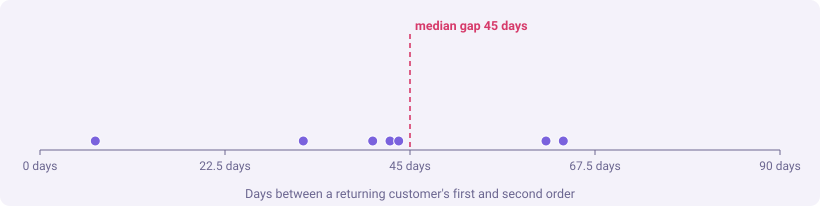

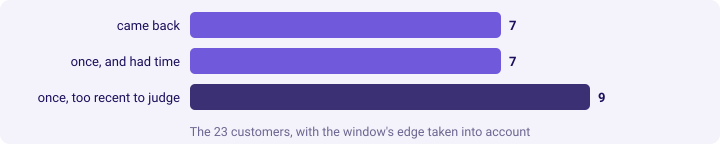

In [5]:
gaps = sorted((max(d) - min(d)).days for d in by_customer.values() if len(d) > 1)
typical_gap = gaps[len(gaps) // 2]
too_recent = [cid for cid in once_ids if (end - by_customer[cid][0]).days < typical_gap]
had_time = len(once_ids) - len(too_recent)
kit.strip(gaps, markers=[("median gap", typical_gap, "bad")], lo=0, hi=90, fmt=lambda v: f"{v:g} days",
          title="Days between a returning customer's first and second order")
kit.bars([("came back", customers - len(once_ids)), ("once, and had time", had_time),
          ("once, too recent to judge", len(too_recent))], lit=(2,),
         title="The 23 customers, with the window's edge taken into account")
kit.check("the median gap between two orders is 45 days", typical_gap == 45, gaps)
kit.check("9 of the 16 one-time buyers bought within the last 45 days", len(too_recent) == 9)
kit.check("7 came back, 7 had time and did not, 9 are too recent",
          (customers - len(once_ids), had_time, len(too_recent)) == (7, 7, 9))

**The fix, and what changed.** The answer is c. The seven who came back took a median of 45 days
to do it, and 9 of the 16 one-time buyers placed their order inside the last 45 days of the
window, so they have not had a typical customer's time to return. What the file supports is
7 came back, 7 had time and have not, and 9 are too recent to judge: the "70 percent lost"
becomes at most 7 of 23, and even those are a guess from 7 gaps. The gap itself rests on 7
customers, which is one more thing the sentence should not claim beyond.

## 2. The build: the sentence from the numbers

Every number in the sentence comes from a variable, so the sentence cannot drift from the work.

**Predict before you run.** Which part does the sentence put last?

- a) The evidence.
- b) What happens to the Rs 12 crore.
- c) The branch.
- d) The caveat.

On the 30 booked orders from 1 July to 26 September, 23 customers placed 1.30 orders each at a typical order of Rs 2,205; 7 came back, 7 have had time and not returned, and 9 bought too recently to judge, so I would open frequency before acquisition, and since one quarter cannot show which branch moved, hold the Rs 12 crore until Tuesday's two quarters.
66 words


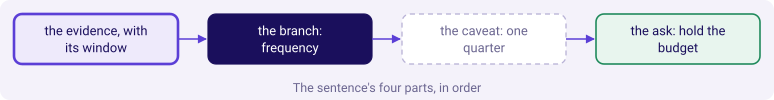

In [6]:
revenue = sum(o["amount"] for o in ORDERS)
amounts = sorted(o["amount"] for o in ORDERS)
median = (amounts[14] + amounts[15]) / 2
per_customer = len(ORDERS) / customers
came_back = customers - len(once_ids)
sentence = (f"On the {len(ORDERS)} booked orders from 1 July to 26 September, {customers} customers placed "
            f"{per_customer:.2f} orders each at a typical order of {kit.rupees(median)}; {came_back} came back, "
            f"{had_time} have had time and not returned, and {len(too_recent)} bought too recently to judge, "
            f"so I would open frequency before acquisition, and since one quarter cannot show which branch "
            f"moved, hold the Rs 12 crore until Tuesday's two quarters.")
print(sentence)
print(len(sentence.split()), "words")
kit.flow(["the evidence, with its window", "the branch: frequency", "the caveat: one quarter",
          "the ask: hold the budget"], kinds=["known", "lit", "unknown", "good"],
         title="The sentence's four parts, in order")

In [7]:
kit.check("the sentence carries the customers, the rate and the typical order",
          str(customers) in sentence and f"{per_customer:.2f}" in sentence and kit.rupees(median) in sentence)
kit.check("the sentence splits the one-time buyers", str(len(too_recent)) in sentence and str(had_time) in sentence)
kit.check("the sentence names what one quarter cannot show", "cannot show" in sentence)
kit.check("the sentence ends on the budget", sentence.rstrip(".").endswith("two quarters"))

**What happened.** The answer is b. The order is the review's order: evidence first so Meera can
weigh it, the branch, the limit, and the ask she acts on. The sentence carries no "lost" and no
percentage marketing can recompute into a different story.

> **Kavya's review.** This is a sentence I would take into the room. It says what we know, what
> we would do, and what we would need before spending Rs 12 crore, and every number in it is
> one we can defend.

## A second route: due dates

The same split comes from the other direction: give each one-time buyer a due date, their
order date plus the typical gap, and count those whose due date falls after the window ends.
The count must match the recency route.

In [8]:
from datetime import timedelta
due_after_end = [cid for cid in once_ids if by_customer[cid][0] + timedelta(days=typical_gap) > end]
kit.table(["route", "one-time buyers too recent to judge"],
          [("days since the order, under the typical gap", len(too_recent)),
           ("due date after the window ends", len(due_after_end))],
          caption="Two routes to the same caveat")
kit.check("both routes find the same customers", set(due_after_end) == set(too_recent))

route,one-time buyers too recent to judge
"days since the order, under the typical gap",9
due date after the window ends,9


**When to switch.** Recency is the route when you report today's state; due dates are the route
when you plan follow-ups, since a due date is the day a reminder would go out. Both need the
gap; with more quarters the gap would come from hundreds of customers instead of 7, and the
caveat would shrink.

### In the interview

**[D] You have one quarter of orders and 70 percent of customers bought once; what do you tell
the CEO?** "That 70 percent bought once in this window, which is a fact, and that it is not a
churn rate. Customers who came back took a median of 45 days, and 9 of the 16 one-time buyers
bought within the last 45 days, so they have not had time. I would say 7 came back, 7 had time
and did not, 9 are too recent, and ask for the prior quarter before calling anyone lost."

**[F] How do you write a recommendation a stakeholder can act on?** "One sentence in four
parts: the evidence with its window and definition, the recommendation, what the evidence
cannot show, and the decision it asks for. Every number comes from the analysis, not retyped,
and none can be recomputed into a different story by the person who disagrees."

**[D] When would you replace this sentence with a dashboard?** "When the question recurs on a
schedule and the definitions are settled, so the build cost is paid back every week. Until
then a sentence with its caveat is faster and harder to misread."

### Depth: the window's edge in every metric

Any count of "who has not done X yet" is cut short at the end of the window: returns that
arrive late, renewals not yet due, a cohort one month old. The dossier's returns-rate trap is
the same edge. The fix is always the same: measure how long X usually takes, and hold back
judgement on everyone who has not had that long.

## What this chapter established

In [9]:
kit.table(["What we now know", "The evidence"],
          [("One-time buyers are not lost customers", "median repeat gap 45 days; 9 of 16 too recent"),
           ("The sentence has four parts in a fixed order", f"{len(sentence.split())} words, every number from a variable"),
           ("The Rs 12 crore waits for a second quarter", "one window shows shape, two show movement")],
          caption="Chapter 6: the sentence Meera acts on")
kit.check_summary()
print("Next: the escalated case asks the same question on the delivered definition, alone.")

What we now know,The evidence
One-time buyers are not lost customers,median repeat gap 45 days; 9 of 16 too recent
The sentence has four parts in a fixed order,"66 words, every number from a variable"
The Rs 12 crore waits for a second quarter,"one window shows shape, two show movement"


Next: the escalated case asks the same question on the delivered definition, alone.
